# Soldani - Second task - Benchmark Extension

## Context: what this notebook adds

`2_1_benchmark_gpt.ipynb` compares FairMind against a single LLM call. This notebook keeps that setup unchanged - same dataset, same SFM roles, same identification formulae written into the prompt - and varies exactly one thing: the `reasoning.effort` parameter of OpenAI's `o3-mini`, swept across `low`, `medium` and `high`.

The question is whether letting the model reason longer produces measurably better causal effect estimates, and what that costs in tokens and latency.

The results below do not support a simple "more effort is better" reading. The middle setting is the most accurate on three of the five effects (TE, DE and, marginally, TV), `high` is best only on IE, and `high` is the *worst* of the three on SE. Token usage does grow steadily with effort (64k -> 72k -> 74k), but response time does not order cleanly: the `medium` run was the fastest of the three at 165s, against 194s for `low` and 217s for `high`.

## 1. Initial setup

Locates the repository root by walking up from the current working directory until it finds the `src/` package, then adds it to `sys.path` so the `src.*` modules can be imported regardless of where Jupyter was launched from.

In [ ]:
# Find the root
from pathlib import Path
import sys

# Find the root by searching the "src" folder
current = Path.cwd()

while current != current.parent:
    if (current / "src").exists():
        REPO_ROOT = current
        break
    current = current.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

## 2. Imports and LLM client configuration

Imports the FairMind building blocks (`build_sfm`, `fit_discrete_bayesian_model`, the effect functions) and instantiates an `OpenAI()` client. Unlike `2_3_benchmark_thor.ipynb`, which talks to a local `llama.cpp` server, this notebook calls the hosted OpenAI API, so the client reads its credentials from the environment and no host or port is configured here.

In [ ]:
import json
import pandas as pd

from openai import OpenAI
from pgmpy.estimators import BayesianEstimator
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.effects import (
    total_variation, total_effect,
    natural_direct_effect, natural_indirect_effect,
)

client = OpenAI()

/Users/marcosoldani/Desktop/SUPSI/tesi/fairmind-causal-fairness-analysis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Benchmark configuration

Defines the Standard Fairness Model roles for this run on the Adult dataset: `S2_gender` as the protected attribute X (`x0`=Female, `x1`=Male), `T_income` as the outcome Y (target state `>50K`), `hours-per-week` as the mediator W, `education` as the confounder Z.

In [3]:
CONFIG = {
    "dataset_name": "adult",
    "csv_path": "../../data/processed/adult.csv",
    "target_col":  "T_income",
    "target_val":  ">50K",
    "protected":   "S2_gender",
    "x0": "Female",
    "x1": "Male",
    "mediators":   ["hours-per-week"],
    "confounders": ["education"],
}

## 4. FairMind - exact ground truth

Builds the SFM graph, fits a Discrete Bayesian Network with BDeu-smoothed parameter estimation, and computes the five causal fairness effects by exact inference. This is the reference against which every LLM answer below is compared.

Two details are worth flagging:

- `df.astype(str)` casts every column to string before fitting, so `hours-per-week` is treated as an unordered categorical variable rather than a numeric one.
- `SE` is derived as `TV - TE` (Eq. 3, Plečko and Bareinboim 2024) from the `tv` and `te` already computed above, which is the same identity the prompt asks the model to apply. Deriving it rather than computing it separately guarantees that both sides of the comparison refer to the same quantity.

In [4]:
import time

def run_fairmind(config: dict) -> tuple[dict, float]:
    df = pd.read_csv(config["csv_path"])
    cols = (
        [config["protected"]]
        + config["mediators"]
        + config["confounders"]
        + [config["target_col"]]
    )
    df = df[cols].dropna()

    df = df.astype(str)

    sfm = build_sfm(
        sensitive_attr=config["protected"],
        outcome_attr=config["target_col"],
        confounder_attrs=config["confounders"],
        mediator_attrs=config["mediators"],
        sorted_mediators=len(config["mediators"]) > 1,
        sorted_confounders=len(config["confounders"]) > 1,
    )
    bn = fit_discrete_bayesian_model(
        sfm=sfm,
        data=df,
        estimator_instance=(BayesianEstimator, {"prior_type": "BDeu"}),
    )

    target = (config["target_col"], config["target_val"])
    x0, x1 = config["x0"], config["x1"]

    start = time.perf_counter()
    # The five SFM causal fairness quantities (Plecko & Bareinboim, 2024)
    tv = total_variation(bn, target, config["protected"], x0, x1)
    te = total_effect(bn, target, config["protected"], x0, x1)
    effects = {
        "TV": tv,
        "TE": te,
        # SE = TV - TE (Eq. 3, Plecko & Bareinboim 2024), the same identity
        # the prompt asks the model to apply.
        "SE": tv - te,
        "DE": natural_direct_effect(bn, target, config["protected"], x0, x1),
        "IE": natural_indirect_effect(bn, target, config["protected"], x1, x0),
    }
    elapsed = time.perf_counter() - start

    return effects, elapsed

ground_truth, fairmind_time = run_fairmind(CONFIG)
print(f"FairMind - elapsed time: {fairmind_time:.4f}s")
for k, v in ground_truth.items():
    print(f"  {k}: {v:.6f}")

2026-08-09 15:42:40.206 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'BDeu'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S2_gender': 'C', 'hours-per-week': 'C', 'education': 'C', 'T_income': 'C'}
2026-08-09 15:42:40.312 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '>50K'), private_baseline=Female, private_mod=Male


FairMind - elapsed time: 0.0052s
  TV: 0.194470
  TE: 0.183161
  SE: 0.011309
  DE: 0.137049
  IE: -0.046112


## 5. Building the prompt for the LLM

Samples 300 rows (fixed `random_state=42`, so the prompt is reproducible across the three effort levels) and writes them into the prompt as a raw CSV block, together with the SFM variable roles and the five identification formulae. The model is therefore not asked to derive the estimands - only to apply the given formulae to the data in front of it and return a JSON object.

Note: all three runs receive this identical prompt: the only thing that is different across them is `reasoning.effort`.

In [5]:
def build_gpt_prompt(config: dict, n_rows: int = 300) -> str:
    df = pd.read_csv(config["csv_path"])
    cols = (
        [config["protected"]]
        + config["mediators"]
        + config["confounders"]
        + [config["target_col"]]
    )
    df = df[cols].dropna()
    sample = df.sample(n=min(n_rows, len(df)), random_state=42)
    csv_str = sample.to_csv(index=False)

    return f"""You are a causal fairness expert. Compute five causal fairness effects
using the Standard Fairness Model (SFM) by Plecko and Bareinboim (2024).

DATASET ({len(sample)} rows):
{csv_str}

VARIABLE ROLES:
- X (protected): "{config['protected']}", x0="{config['x0']}", x1="{config['x1']}"
- Y (target):    "{config['target_col']}", target state="{config['target_val']}"
- W (mediators): {config['mediators']}
- Z (confounders): {config['confounders']}

IDENTIFICATION FORMULAE (use these exactly):
- TV = P(Y=y | X=x1) - P(Y=y | X=x0)
- TE = sum_z [P(Y=y|x1,z) - P(Y=y|x0,z)] * P(z)
- SE = TV - TE
- DE = sum_z,w [P(Y=y|x1,w,z) - P(Y=y|x0,w,z)] * P(w|x0,z) * P(z)
- IE = sum_z,w P(Y=y|x0,w,z) * [P(w|x1,z) - P(w|x0,z)] * P(z)

Return ONLY a JSON object, no other text:
{{
  "TV": <float>,
  "TE": <float>,
  "SE": <float>,
  "DE": <float>,
  "IE": <float>
}}"""

prompt = build_gpt_prompt(CONFIG)
print(prompt[:600], "\n[...]")

You are a causal fairness expert. Compute five causal fairness effects
using the Standard Fairness Model (SFM) by Plecko and Bareinboim (2024).

DATASET (300 rows):
S2_gender,hours-per-week,education,T_income
Female,40,HS-grad,<=50K
Male,40,HS-grad,<=50K
Female,40,Bachelors,>50K
Male,40,HS-grad,<=50K
Female,30,Bachelors,<=50K
Female,40,HS-grad,<=50K
Male,45,HS-grad,<=50K
Female,40,Bachelors,>50K
Male,50,HS-grad,<=50K
Female,40,Some-college,<=50K
Male,70,Some-college,<=50K
Male,30,Bachelors,<=50K
Male,40,Some-college,<=50K
Male,45,11th,<=50K
Male,40,Bachelors,<=50K
Male,60,Assoc-voc,<=50K
Femal 
[...]


## 6. Calling the model at three reasoning effort levels

Sends the same prompt three times, once per effort level, recording latency and token usage for each. No `temperature` is passed here - the reasoning models expose `reasoning.effort` in its place - so the runs are not sampled at temperature 0 the way `2_1` was, and repeating this cell would not necessarily reproduce these exact numbers.

The response text is stripped of its Markdown code fences before `json.loads`, since the model tends to wrap the JSON in ```` ```json ```` despite the prompt asking for bare JSON.

The `reasoning_tokens` field is the interesting one: it shows roughly 30k, 34k and 35k tokens spent on internal reasoning for low, medium and high respectively - i.e. the bulk of the output budget goes to reasoning the user never sees.

In [ ]:
def call_gpt_effort(prompt: str, effort: str, model: str = "o3-mini") -> tuple[dict, dict, float]:
    start = time.perf_counter()
    response = client.responses.create(
        model=model,
        reasoning={"effort": effort},
        input=[
            {
                "role": "user",
                "content": [{"type": "input_text", "text": prompt}],
            }
        ],
    )
    elapsed = time.perf_counter() - start

    usage = {
        "effort":           effort,
        "input_tokens":     response.usage.input_tokens,
        "output_tokens":    response.usage.output_tokens,
        "reasoning_tokens": response.usage.output_tokens_details.reasoning_tokens,
        "total_tokens":     response.usage.total_tokens,
    }

    # JSON Parsing
    raw = response.output_text.strip()
    
    # Remove backticks
    raw = response.output_text.strip().replace("```json", "").replace("```", "").strip()
    effects = json.loads(raw)

    return effects, usage, elapsed

EFFORTS = ["low", "medium", "high"]
gpt_runs = {}

for effort in EFFORTS:
    print(f"Call to GPT with effort='{effort}'...")
    gpt_effects, gpt_usage, gpt_time = call_gpt_effort(prompt, effort=effort)
    gpt_runs[effort] = {"effects": gpt_effects, "usage": gpt_usage, "time": gpt_time}
    print(f"  time: {gpt_time:.3f}s | "
          f"input: {gpt_usage['input_tokens']} | "
          f"output: {gpt_usage['output_tokens']} | "
          f"reasoning: {gpt_usage['reasoning_tokens']} | "
          f"total: {gpt_usage['total_tokens']}")
    print(json.dumps(gpt_effects, indent=2))

Call to GPT with effort='low'...
  time: 194.026s | input: 3662 | output: 60739 | reasoning: 30336 | total: 64401
{
  "TV": 0.1825,
  "TE": 0.15,
  "SE": 0.0325,
  "DE": 0.08,
  "IE": 0.07
}
Call to GPT with effort='medium'...
  time: 165.160s | input: 3662 | output: 68598 | reasoning: 34240 | total: 72260
{
  "TV": 0.18254,
  "TE": 0.19278,
  "SE": -0.01024,
  "DE": 0.16278,
  "IE": 0.03
}
Call to GPT with effort='high'...
  time: 216.532s | input: 3662 | output: 69868 | reasoning: 34880 | total: 73530
{
  "TV": 0.1825,
  "TE": 0.2125,
  "SE": -0.03,
  "DE": 0.1925,
  "IE": 0.02
}


## 7. Comparing FairMind vs LLM at each effort

Computes the absolute and relative error between the ground truth and each of the three LLM answers, one table per effort level.

The pattern across the three tables: TV is estimated well at every effort (~6% relative error, since it is a plain conditional difference requiring no adjustment), while the effects that require summing over Z and W degrade badly. IE has the wrong sign in all three runs, and SE has the wrong sign in two of the three.

In [7]:
def compute_discrepancies(ground_truth: dict, gpt_effects: dict) -> pd.DataFrame:
    rows = []
    for effect in ["TV", "TE", "SE", "DE", "IE"]:
        gt  = ground_truth.get(effect, float("nan"))
        gpt = float(gpt_effects.get(effect, float("nan")))
        abs_err = abs(gt - gpt)
        rel_err = abs_err / abs(gt) if abs(gt) > 1e-9 else float("nan")
        rows.append({
            "effect":      effect,
            "fairmind":    round(gt,  6),
            "gpt":         round(gpt, 6),
            "abs_error":   round(abs_err, 6),
            "rel_error_%": round(rel_err * 100, 2) if not pd.isna(rel_err) else float("nan"),
        })
    return pd.DataFrame(rows)

discrepancies_by_effort = {}

for effort, run in gpt_runs.items():
    disc = compute_discrepancies(ground_truth, run["effects"])
    disc["effort"] = effort
    discrepancies_by_effort[effort] = disc
    print(f"\n--- effort={effort} ---")
    print(disc.to_string(index=False))


--- effort=low ---
effect  fairmind    gpt  abs_error  rel_error_% effort
    TV  0.194470 0.1825   0.011970         6.16    low
    TE  0.183161 0.1500   0.033161        18.11    low
    SE  0.011309 0.0325   0.021191       187.38    low
    DE  0.137049 0.0800   0.057049        41.63    low
    IE -0.046112 0.0700   0.116112       251.80    low

--- effort=medium ---
effect  fairmind      gpt  abs_error  rel_error_% effort
    TV  0.194470  0.18254   0.011930         6.13 medium
    TE  0.183161  0.19278   0.009619         5.25 medium
    SE  0.011309 -0.01024   0.021549       190.55 medium
    DE  0.137049  0.16278   0.025731        18.77 medium
    IE -0.046112  0.03000   0.076112       165.06 medium

--- effort=high ---
effect  fairmind     gpt  abs_error  rel_error_% effort
    TV  0.194470  0.1825   0.011970         6.16   high
    TE  0.183161  0.2125   0.029339        16.02   high
    SE  0.011309 -0.0300   0.041309       365.27   high
    DE  0.137049  0.1925   0.055451     

## 8. Visualising the comparison

Three panels: absolute error per effect grouped by effort, stacked token usage per effort and response time per effort with the FairMind runtime used as a reference line.

The runtime comparison is the clearest result in this notebook - FairMind computes all five effects exactly in roughly 5 milliseconds, against 165-217 seconds for the model, a gap of roughly four and a half orders of magnitude - and the model's answers still carry relative errors ranging from about 6% on TV to several hundred percent on SE and IE.

The figure saved as `{dataset}_all_efforts_{timestamp}_plot.png` aggregates all effort levels.

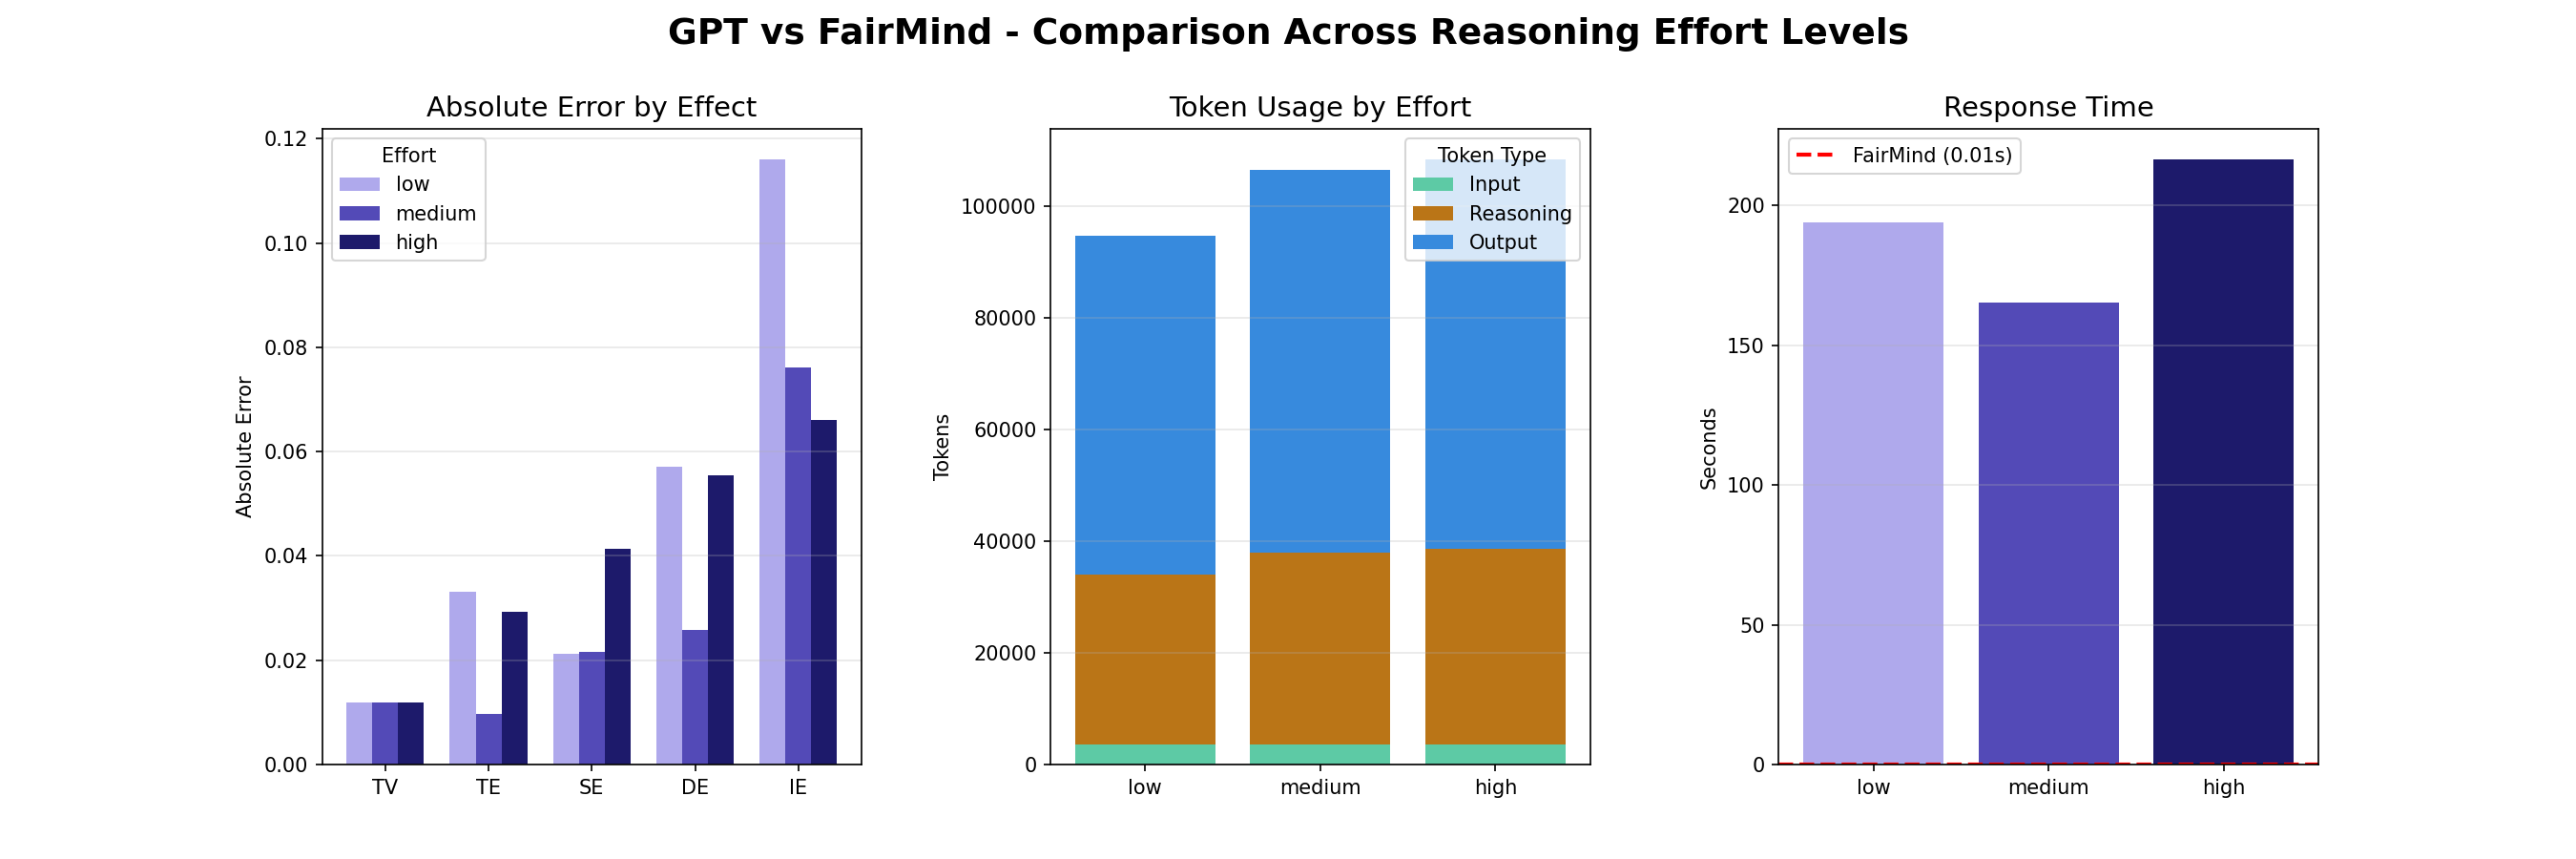

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import datetime

config = CONFIG["dataset_name"]
efforts = EFFORTS
effects = ["TV", "TE", "SE", "DE", "IE"]
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

colors = {
    "low": "#AFA9EC",
    "medium": "#534AB7",
    "high": "#1D1A6B"
}

x = np.arange(len(effects))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)

fig.suptitle(
    "GPT vs FairMind - Comparison Across Reasoning Effort Levels",
    fontsize=18,
    fontweight="bold"
)

# ==========================
# Chart 1
# ==========================
ax = axes[0]

for i, effort in enumerate(efforts):
    vals = discrepancies_by_effort[effort]["abs_error"].tolist()

    ax.bar(
        x + (i - 1) * width,
        vals,
        width,
        label=effort,
        color=colors[effort]
    )

ax.set_title("Absolute Error by Effect", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(effects)
ax.set_ylabel("Absolute Error")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Effort")

# ==========================
# Chart 2
# ==========================
ax = axes[1]

token_types = [
    "input_tokens",
    "reasoning_tokens",
    "output_tokens"
]

token_labels = [
    "Input",
    "Reasoning",
    "Output"
]

token_colors = [
    "#5DCAA5",
    "#BA7517",
    "#378ADD"
]

bottoms = np.zeros(len(efforts))

for tok, lbl, col in zip(token_types, token_labels, token_colors):
    vals = [gpt_runs[e]["usage"][tok] for e in efforts]

    ax.bar(
        efforts,
        vals,
        bottom=bottoms,
        label=lbl,
        color=col
    )

    bottoms += np.array(vals)

ax.set_title("Token Usage by Effort", fontsize=14)
ax.set_ylabel("Tokens")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Token Type")

# ==========================
# Chart 3
# ==========================
ax = axes[2]

times = [gpt_runs[e]["time"] for e in efforts]

ax.bar(
    efforts,
    times,
    color=[colors[e] for e in efforts]
)

ax.axhline(
    fairmind_time,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"FairMind ({fairmind_time:.2f}s)"
)

ax.set_title("Response Time", fontsize=14)
ax.set_ylabel("Seconds")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.subplots_adjust(
    top=0.85,
    wspace=0.35
)

plt.savefig(
    f"benchmark_results/{config}_all_efforts_{ts}_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Saving results to disk

Writes configuration, both sets of effects, the discrepancy table, token usage and timing to one timestamped JSON file per effort level inside the `benchmark_results/` folder.

In [9]:
def save_results(config, ground_truth, gpt_effects, discrepancies, usage, fairmind_time, gpt_time, effort):
    import os, datetime
    os.makedirs("benchmark_results", exist_ok=True)
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    fname = f"benchmark_results/{config['dataset_name']}_{effort}_{ts}.json"

    out = {
        "dataset":       config["dataset_name"],
        "effort":        effort,
        "config":        {k: v for k, v in config.items() if k != "csv_path"},
        "fairmind":      ground_truth,
        "gpt":           gpt_effects,
        "discrepancies": discrepancies.to_dict(orient="records"),
        "token_usage":   usage,
        "timing": {
            "fairmind_seconds": round(fairmind_time, 5),
            "gpt_seconds":      round(gpt_time, 5),
        },
    }
    with open(fname, "w") as f:
        json.dump(out, f, indent=2)
    print(f"Saved: {fname}")

for effort, run in gpt_runs.items():
    save_results(
        config=CONFIG, 
        ground_truth=ground_truth, 
        gpt_effects=run["effects"],
        discrepancies=discrepancies_by_effort[effort],
        usage=run["usage"],
        fairmind_time=fairmind_time,
        gpt_time=run["time"],
        effort=effort,
    )

Saved: benchmark_results/adult_low_20260622_115443.json
Saved: benchmark_results/adult_medium_20260622_115443.json
Saved: benchmark_results/adult_high_20260622_115443.json
